h = 0.1 failed/diverged at t = 0.3000
h = 0.01 failed/diverged at t = 0.0600
h = 1e-05 skipped: requires 3000000 steps (max is 1000000)


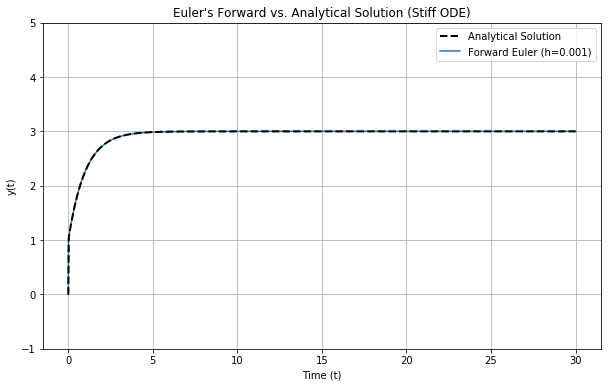

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the ODE and the Analytical Solution
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def exact_sol(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

# 2. Meshed Euler Function with stability safeguards
def forward_euler(y0, h, t_start, t_stop, max_steps=1_000_000):
    num_steps = int(round((t_stop - t_start) / h))
    
    # Safety check for memory/time (from your 3rd snippet)
    if num_steps > max_steps:
        print(f"h = {h} skipped: requires {num_steps} steps (max is {max_steps})")
        return None, None

    t_vals = np.linspace(t_start, t_stop, num_steps + 1)
    y_vals = np.zeros(num_steps + 1)
    y_vals[0] = y0

    for i in range(num_steps):
        # Euler Formula: y_next = y_current + h * f(t, y)
        y_vals[i+1] = y_vals[i] + h * f(t_vals[i], y_vals[i])
        
        # Divergence check: if y blows up due to stiffness
        if not np.isfinite(y_vals[i+1]) or abs(y_vals[i+1]) > 1e5:
            print(f"h = {h} failed/diverged at t = {t_vals[i+1]:.4f}")
            return None, None
            
    return t_vals, y_vals

# 3. Execution and Plotting
t0, tf = 0, 30
y0 = 0
h_values = [0.1, 0.01, 0.001, 0.00001] # Removed 1e-7 to keep execution fast

plt.figure(figsize=(10, 6))

# Plot Analytical Solution
t_exact = np.linspace(t0, tf, 1000)
plt.plot(t_exact, exact_sol(t_exact), 'k--', linewidth=2, label='Analytical Solution', zorder=5)

# Loop through step sizes and plot Euler results
for h in h_values:
    t_euler, y_euler = forward_euler(y0, h, t0, tf)
    
    if t_euler is not None:
        plt.plot(t_euler, y_euler, label=f"Forward Euler (h={h})")

# Formatting
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title("Euler's Forward vs. Analytical Solution (Stiff ODE)")
plt.legend()
plt.grid(True)
plt.ylim(-1, 5) # Limits view so diverged lines don't squash the plot
plt.show()